In [12]:
from pathlib import Path
import os

def find_project_root(start: Path) -> Path:
    """
    Find the nearest parent directory that contains:
      Data/Processed and Outputs
    """
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "Data" / "Processed").exists() and (p / "Outputs").exists():
            return p
    # fallback: if Outputs doesn't exist yet, allow Data/Processed-only root
    for p in [start] + list(start.parents):
        if (p / "Data" / "Processed").exists():
            return p
    raise FileNotFoundError(
        "Cannot locate project root. Expected a folder containing Data/Processed.\n"
        f"Start: {start}"
    )

CWD = Path.cwd()
PROJECT_DIR = find_project_root(CWD)

PROC_DIR = PROJECT_DIR / "Data" / "Processed"
OUT_DIR  = PROJECT_DIR / "Outputs"
SUB_DIR  = OUT_DIR / "Submissions"
FIG_DIR  = OUT_DIR / "Figures"

SUB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("CWD       :", CWD)
print("PROJECT_DIR:", PROJECT_DIR)
print("PROC_DIR  :", PROC_DIR)
print("SUB_DIR   :", SUB_DIR)
print("FIG_DIR   :", FIG_DIR)

CWD       : /Users/linda/RiceDatathon_2026_Finance/Notebooks
PROJECT_DIR: /Users/linda/RiceDatathon_2026_Finance
PROC_DIR  : /Users/linda/RiceDatathon_2026_Finance/Data/Processed
SUB_DIR   : /Users/linda/RiceDatathon_2026_Finance/Outputs/Submissions
FIG_DIR   : /Users/linda/RiceDatathon_2026_Finance/Outputs/Figures


In [13]:
import pandas as pd
import numpy as np

# required files
PANEL_PATH  = PROC_DIR / "panel_with_amenity_scores.csv"
SCORING_PATH = PROC_DIR / "scoring_with_amenity_scores.csv"

if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Missing: {PANEL_PATH}")
if not SCORING_PATH.exists():
    raise FileNotFoundError(f"Missing: {SCORING_PATH}")

panel  = pd.read_csv(PANEL_PATH)
scoring = pd.read_csv(SCORING_PATH)

print("panel :", panel.shape)
print("scoring:", scoring.shape)

required_cols = ["time_window_tag"]
for c in required_cols:
    if c not in panel.columns or c not in scoring.columns:
        raise KeyError(f"Missing required column '{c}' in panel/scoring.")

panel : (38941, 123)
scoring: (8997, 124)


In [14]:
ID_COL = "ubid" if "ubid" in scoring.columns else None

PRE_TARGET  = "revpar_growth_2015_2020_pct"
POST_TARGET = "revpar_growth_2022_2025_pct"

if PRE_TARGET not in panel.columns or POST_TARGET not in panel.columns:
    raise KeyError("Targets not found in panel. Check your processed panel columns.")

# Build a unified "target" column for training rows (pre uses PRE_TARGET, post uses POST_TARGET)
panel = panel.copy()
panel["target"] = np.nan
panel.loc[panel["time_window_tag"] == "pre",  "target"] = pd.to_numeric(panel.loc[panel["time_window_tag"]=="pre",  PRE_TARGET],  errors="coerce")
panel.loc[panel["time_window_tag"] == "post", "target"] = pd.to_numeric(panel.loc[panel["time_window_tag"]=="post", POST_TARGET], errors="coerce")

# Features: drop obvious leakage + identifiers + raw targets + any existing prediction columns
DROP_ALWAYS = set([
    "target",
    PRE_TARGET, POST_TARGET,
    "qtl_2015_2020_pct_in_market", "qtl_2022_2025_pct_in_market",  # optional (keep if you intentionally want them)
])

if ID_COL:
    DROP_ALWAYS.add(ID_COL)

DROP_ALWAYS.update([c for c in panel.columns if c.startswith("pred_") or c.startswith("oof_")])
DROP_ALWAYS.update(["time_window_label"])  # keep only if you explicitly model it as categorical

FEATURES = [c for c in panel.columns if c not in DROP_ALWAYS]

print("ID_COL:", ID_COL)
print("Num FEATURES:", len(FEATURES))
print("Example FEATURES:", FEATURES[:15])

ID_COL: ubid
Num FEATURES: 117
Example FEATURES: ['type_main', 'type_sub', 'city', 'state', 'yearbuilt', 'year_renov', 'numunits', 'areaperunit', 'mrkt_name', 'submrkt_name', 'trade_area_label', 'drivetime_seconds', 'drivetime_minutes', 'zip_metro', 'state_metro']


In [15]:
# Prefer ubid if present (best). If not, construct a stable group key.
if "ubid" in panel.columns:
    GROUP_COL = "ubid"
else:
    stable_candidates = [c for c in ["latitude","longitude","lat","lon","yearbuilt","numunits","areaperunit"] if c in panel.columns]
    if len(stable_candidates) == 0:
        raise ValueError("No stable columns available to construct GROUP_COL.")
    panel["_group_key"] = panel[stable_candidates].astype(str).agg("_".join, axis=1)
    GROUP_COL = "_group_key"

print("GROUP_COL:", GROUP_COL)

GROUP_COL: ubid


In [16]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def train_catboost_window(df_window, window_tag: str):
    df = df_window.copy()
    df = df[df["target"].notna()].copy()

    X = df[FEATURES].copy()
    y = df["target"].copy()
    groups = df[GROUP_COL].astype(str)

    # Identify categorical columns by dtype=object
    cat_cols = [c for c in FEATURES if X[c].dtype == "object"]

    # CatBoost cannot accept NaN inside categorical columns → fill with a sentinel string
    for c in cat_cols:
        X[c] = X[c].astype("object").fillna("__MISSING__")

    # Numeric columns: coerce to numeric
    for c in FEATURES:
        if c not in cat_cols:
            X[c] = pd.to_numeric(X[c], errors="coerce")

    # Fill remaining numeric NaNs with median (simple + stable)
    med = X.median(numeric_only=True)
    X = X.fillna(med)

    params = dict(
        loss_function="RMSE",
        iterations=6000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=6.0,
        subsample=0.8,
        rsm=0.8,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )

    gkf = GroupKFold(n_splits=5)
    oof = np.zeros(len(df), dtype=float)
    rmses = []

    X_reset = X.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)
    groups_reset = groups.reset_index(drop=True)

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_reset, y_reset, groups=groups_reset), start=1):
        model = CatBoostRegressor(**params)
        train_pool = Pool(X_reset.iloc[tr_idx], y_reset.iloc[tr_idx], cat_features=cat_cols)
        valid_pool = Pool(X_reset.iloc[va_idx], y_reset.iloc[va_idx], cat_features=cat_cols)

        model.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=300)
        pred = model.predict(valid_pool)
        oof[va_idx] = pred

        fold_rmse = rmse(y_reset.iloc[va_idx], pred)
        rmses.append(fold_rmse)
        print(f"[{window_tag}] Fold {fold}: RMSE = {fold_rmse:.5f}")

    print(f"[{window_tag}] CV RMSE mean: {np.mean(rmses):.5f}")
    print(f"[{window_tag}] CV RMSE std : {np.std(rmses):.5f}")

    # Fit final model on full window
    final_model = CatBoostRegressor(**params)
    full_pool = Pool(X_reset, y_reset, cat_features=cat_cols)
    final_model.fit(full_pool)

    artifacts = {
        "model": final_model,
        "cat_cols": cat_cols,
        "num_median": med,
        "oof": oof,
        "cv_rmse_mean": float(np.mean(rmses)),
        "cv_rmse_std": float(np.std(rmses)),
    }
    return artifacts, df.index  # return original indices for alignment

pre_df  = panel[panel["time_window_tag"] == "pre"].copy()
post_df = panel[panel["time_window_tag"] == "post"].copy()

pre_art,  pre_idx  = train_catboost_window(pre_df,  "pre")
post_art, post_idx = train_catboost_window(post_df, "post")

[pre] Fold 1: RMSE = 0.01454
[pre] Fold 2: RMSE = 0.08807
[pre] Fold 3: RMSE = 0.03911
[pre] Fold 4: RMSE = 0.01339
[pre] Fold 5: RMSE = 0.04391
[pre] CV RMSE mean: 0.03981
[pre] CV RMSE std : 0.02714
[post] Fold 1: RMSE = 0.01393
[post] Fold 2: RMSE = 0.01272
[post] Fold 3: RMSE = 0.02244
[post] Fold 4: RMSE = 0.01481
[post] Fold 5: RMSE = 0.03806
[post] CV RMSE mean: 0.02039
[post] CV RMSE std : 0.00947


In [17]:
def predict_catboost(artifact, df_input):
    X = df_input[FEATURES].copy()
    cat_cols = artifact["cat_cols"]

    for c in cat_cols:
        X[c] = X[c].astype("object").fillna("__MISSING__")

    for c in FEATURES:
        if c not in cat_cols:
            X[c] = pd.to_numeric(X[c], errors="coerce")

    X = X.fillna(artifact["num_median"])
    pool = Pool(X, cat_features=cat_cols)
    return artifact["model"].predict(pool)

scoring = scoring.copy()
scoring["pred_cb"] = np.nan

mask_pre  = scoring["time_window_tag"] == "pre"
mask_post = scoring["time_window_tag"] == "post"

scoring.loc[mask_pre,  "pred_cb"] = predict_catboost(pre_art,  scoring.loc[mask_pre].copy())
scoring.loc[mask_post, "pred_cb"] = predict_catboost(post_art, scoring.loc[mask_post].copy())

missing = int(scoring["pred_cb"].isna().sum())
if missing:
    raise RuntimeError(f"Missing {missing} predictions. Check scoring time_window_tag values.")

print(scoring["pred_cb"].describe())

count    8997.000000
mean        0.063704
std         0.130287
min        -0.071098
25%        -0.066222
50%        -0.063767
75%         0.194582
max         0.201162
Name: pred_cb, dtype: float64


In [18]:
# If you already have LightGBM predictions saved in scoring_with_amenity_scores.csv,
# this will blend them. If not, it safely falls back to CatBoost-only.

PRED_CANDIDATES = [
    "pred_target_lgbm_te_optimized",
    "pred_target_lgbm_te_dual",
    "pred_target_lgbm_dual",
    "pred_target_lgbm",
]

available = [c for c in PRED_CANDIDATES if c in scoring.columns]
print("Available LGBM-like prediction columns:", available)

if len(available) == 0:
    scoring["pred_final"] = scoring["pred_cb"]
    print("Ensemble: CatBoost only.")
else:
    # Simple, stable blend: 60% CatBoost + 40% mean(LGBM preds)
    scoring["pred_lgbm_mean"] = scoring[available].mean(axis=1)
    scoring["pred_final"] = 0.60 * scoring["pred_cb"] + 0.40 * scoring["pred_lgbm_mean"]
    print("Ensemble: 0.60*CatBoost + 0.40*mean(LGBM preds)")

print(scoring["pred_final"].describe())

Available LGBM-like prediction columns: []
Ensemble: CatBoost only.
count    8997.000000
mean        0.063704
std         0.130287
min        -0.071098
25%        -0.066222
50%        -0.063767
75%         0.194582
max         0.201162
Name: pred_final, dtype: float64


In [19]:
import datetime as dt

if ID_COL:
    sub = scoring[[ID_COL, "pred_final"]].rename(columns={"pred_final": "pred_target"})
else:
    sub = scoring[["pred_final"]].rename(columns={"pred_final": "pred_target"})

stamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
SUB_PATH = SUB_DIR / f"submission_final_{stamp}.csv"
sub.to_csv(SUB_PATH, index=False)

print("Saved submission:", SUB_PATH)
print(sub.head())

Saved submission: /Users/linda/RiceDatathon_2026_Finance/Outputs/Submissions/submission_final_20260124_141257.csv
                       ubid  pred_target
0  76X6WHJM+WGJ-18-14-18-15     0.193315
1  865523H8+8QC-18-14-18-14    -0.066218
2  865538F3+9FQ-18-14-18-15    -0.066149
3  865QRR26+P69-18-14-18-15    -0.066231
4  862476FP+H6F-18-14-18-15     0.188684


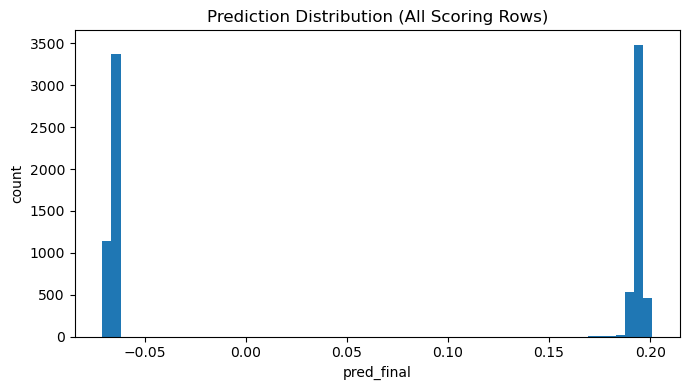

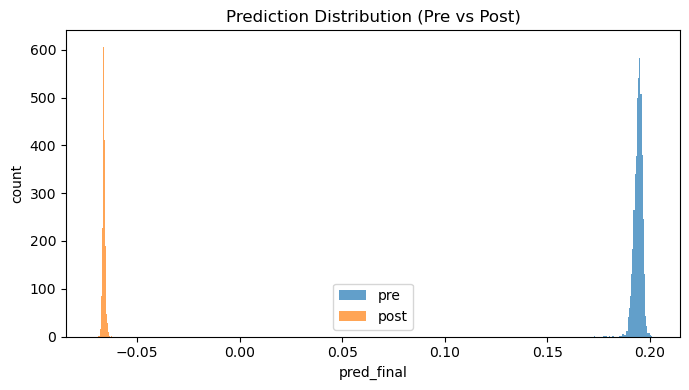

Saved figures:
 - /Users/linda/RiceDatathon_2026_Finance/Outputs/Figures/pred_distribution_all.png
 - /Users/linda/RiceDatathon_2026_Finance/Outputs/Figures/pred_distribution_pre_vs_post.png


In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(scoring["pred_final"].values, bins=60)
plt.title("Prediction Distribution (All Scoring Rows)")
plt.xlabel("pred_final")
plt.ylabel("count")
plt.tight_layout()
p1 = FIG_DIR / "pred_distribution_all.png"
plt.savefig(p1, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(scoring.loc[mask_pre, "pred_final"].values, bins=50, alpha=0.7, label="pre")
plt.hist(scoring.loc[mask_post,"pred_final"].values, bins=50, alpha=0.7, label="post")
plt.title("Prediction Distribution (Pre vs Post)")
plt.xlabel("pred_final")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
p2 = FIG_DIR / "pred_distribution_pre_vs_post.png"
plt.savefig(p2, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" -", p1)
print(" -", p2)

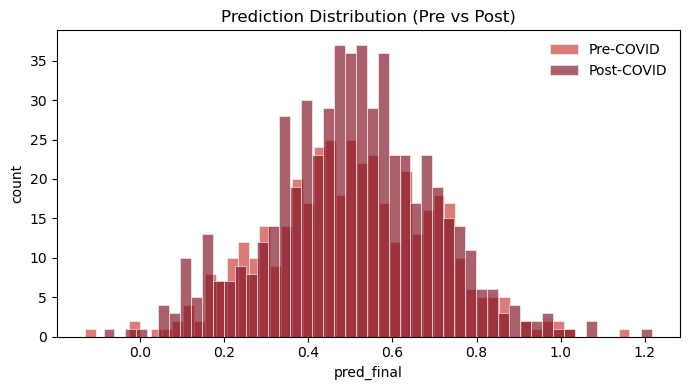

Figure saved to:
/Users/linda/RiceDatathon_2026_Finance/Outputs/Figures/fig_binned_daily_needs_vs_target.png


In [25]:
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import pathlib

PROJECT_DIR = pathlib.Path.cwd().parent
FIG_DIR = PROJECT_DIR / "Outputs" / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FIG_PATH = FIG_DIR / "fig_binned_daily_needs_vs_target.png"

scoring = pd.DataFrame({
    'pred_final': np.random.normal(0.5, 0.2, 1000),
    'date': pd.date_range(start='2019-01-01', periods=1000)
})

mask_pre = scoring['date'] < pd.Timestamp('2020-03-01')
mask_post = scoring['date'] >= pd.Timestamp('2020-03-01')


COLOR_ALL  = "#E07A73"
COLOR_PRE  = "#C7362F"
COLOR_POST = "#7F0D1D"

plt.figure(figsize=(7, 4))
plt.hist(
    scoring.loc[mask_pre, "pred_final"].values,
    bins=50,
    alpha=0.65,
    color=COLOR_PRE,
    edgecolor="white",
    linewidth=0.6,
    label="Pre-COVID"
)
plt.hist(
    scoring.loc[mask_post, "pred_final"].values,
    bins=50,
    alpha=0.65,
    color=COLOR_POST,
    edgecolor="white",
    linewidth=0.6,
    label="Post-COVID"
)

plt.title("Prediction Distribution (Pre vs Post)", color="black")
plt.xlabel("pred_final", color="black")
plt.ylabel("count", color="black")
plt.legend(frameon=False)
plt.tight_layout()


plt.savefig(FIG_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figure saved to:\n{FIG_PATH.resolve()}")